## Dependencies

In [74]:
import pandas as pd
import numpy as np

import torch

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from tqdm.cli import tqdm
from tqdm import trange

import random

tqdm.pandas()

def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
set_all_seeds(2)

In [75]:
df_path = "../data/train.csv"
df_test_path = "../data/test.csv"
df_sample_subm_path = "../data/sample_submission.csv"
images_path = "../data/images"

In [76]:
df = pd.read_csv(df_path)
df_test = pd.read_csv(df_test_path)
df_sample_subm = pd.read_csv(df_sample_subm_path)

## EDA

In [77]:
df.head()

,id,card_identifier_id,label,name,description
0,0,4035,1,Multibook® B6+ Твердый переплет,Представляем Multibook® B6+ — идеальный помощн...
1,1,3003,0,Травяной чай Molecule для похудения,Натуральный травяной чай Molecule — ваш надежн...
2,2,3857,1,Tinta PVA Corfix para Artesanato,Идеальное решение для творчества! Эта высокока...
3,3,4044,1,Red Arrow Notebook with Black Geometric Design,Этот стильный красный дневник с черным геометр...
4,4,269,1,Уютная белая шапка,Эта теплая и стильная белая шапка станет идеал...


In [78]:
df.shape

(34075, 5)

In [79]:
df.isna().sum()

id                    0
card_identifier_id    0
label                 0
name                  0
description           0
dtype: int64

In [80]:
df.duplicated().sum()

np.int64(0)

In [81]:
df['label'].value_counts()

label
1    27372
0     6703
Name: count, dtype: int64

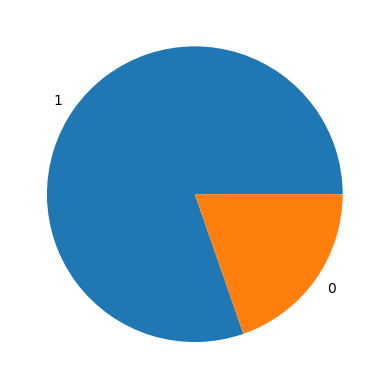

In [82]:
plt.pie(
    x=df['label'].value_counts(),
    labels=['1', '0'],
)
plt.show()

In [83]:
def get_image(id: int) -> Image.Image:
    try:
        img = Image.open(f"{images_path}/{id}.jpg")
    except:
        img = None
    return img

df['img'] = df['id'].progress_apply(get_image)
df.head()

100%|██████████| 34075/34075 [00:03<00:00, 9633.03it/s] 


,id,card_identifier_id,label,name,description,img
0,0,4035,1,Multibook® B6+ Твердый переплет,Представляем Multibook® B6+ — идеальный помощн...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
1,1,3003,0,Травяной чай Molecule для похудения,Натуральный травяной чай Molecule — ваш надежн...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
2,2,3857,1,Tinta PVA Corfix para Artesanato,Идеальное решение для творчества! Эта высокока...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
3,3,4044,1,Red Arrow Notebook with Black Geometric Design,Этот стильный красный дневник с черным геометр...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
4,4,269,1,Уютная белая шапка,Эта теплая и стильная белая шапка станет идеал...,<PIL.JpegImagePlugin.JpegImageFile image mode=...


In [84]:
df.isna().sum()

id                    0
card_identifier_id    0
label                 0
name                  0
description           0
img                   0
dtype: int64

id                                                                10215
card_identifier_id                                                 2608
label                                                                 1
name                                          Букет из конфет Raffaello
description           Подарите незабываемые моменты с этим восхитите...
img                   <PIL.JpegImagePlugin.JpegImageFile image mode=...
Name: 6002, dtype: object


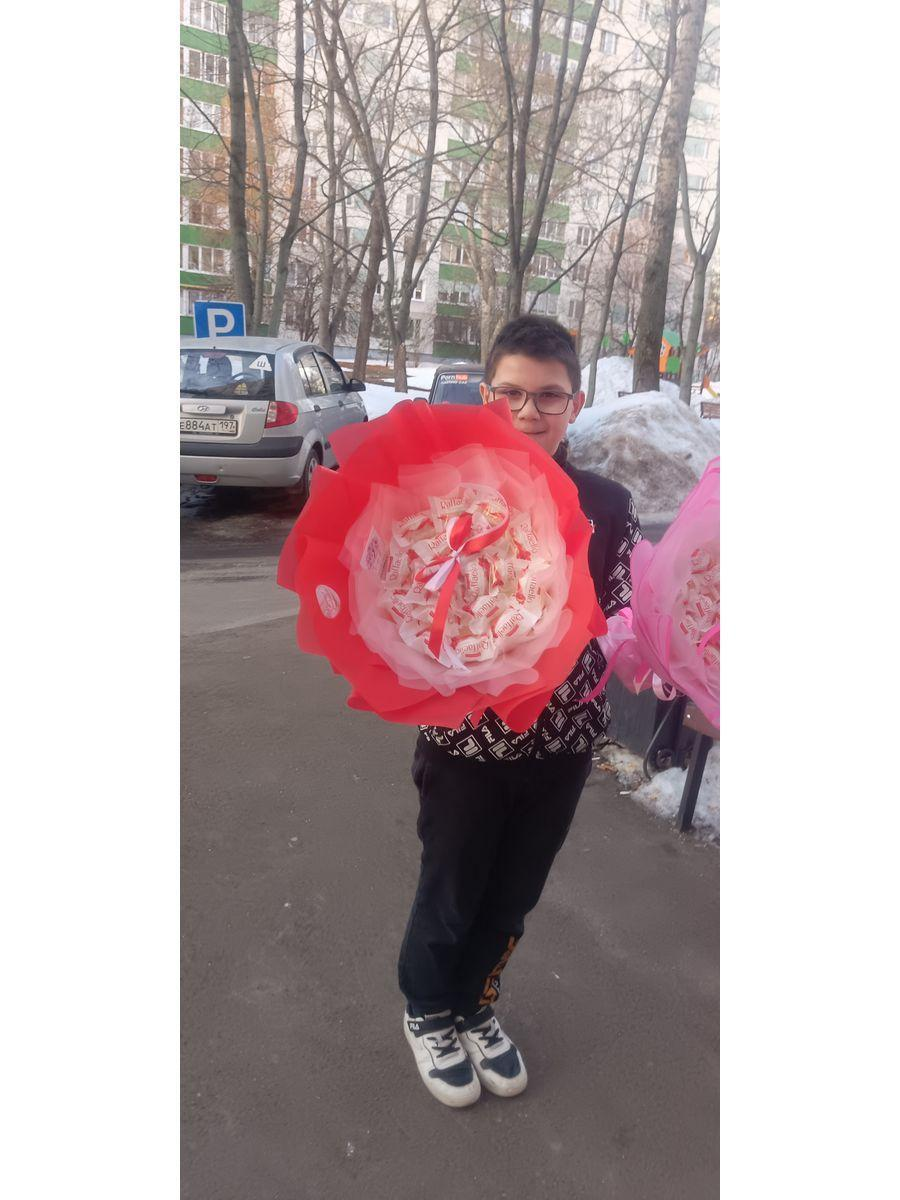

In [86]:
def get_item(ind: int) -> None:
    print(df.iloc[ind])
    display(df.iloc[ind]['img'])

get_item(random.randint(0, df.shape[0] - 1))